<a href="https://colab.research.google.com/github/ptl-harsh/minor_project/blob/main/Image_Caption_Gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Mount drive and unzip the dataset

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# Adjust the path to your zip file accordingly.
!unzip -q '/content/drive/MyDrive/Datasets/img_cap_dataset.zip' -d '/content/'


In [3]:
# Cell 2: Import libraries

import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from nltk.translate.bleu_score import corpus_bleu
import pickle


In [4]:
# Cell 3: Load and process captions

# Path to your captions file (adjust if the file name/path is different)
captions_filepath = '/content/captions.txt'
df = pd.read_csv(captions_filepath)

def clean_caption(caption):
    # Convert to lowercase, remove punctuation and extra spaces.
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = caption.strip()
    return caption

# Create dictionary mapping image name to list of captions
captions_dict = {}
for i, row in df.iterrows():
    img, cap = row['image'], row['caption']
    cap = clean_caption(cap)
    if img not in captions_dict:
        captions_dict[img] = []
    # Add start and end tokens to capture context
    captions_dict[img].append('startseq ' + cap + ' endseq')

# Print sample data
for key in list(captions_dict.keys())[:3]:
    print(key, captions_dict[key])


1000268201_693b08cb0e.jpg ['startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq', 'startseq a girl going into a wooden building endseq', 'startseq a little girl climbing into a wooden playhouse endseq', 'startseq a little girl climbing the stairs to her playhouse endseq', 'startseq a little girl in a pink dress going into a wooden cabin endseq']
1001773457_577c3a7d70.jpg ['startseq a black dog and a spotted dog are fighting endseq', 'startseq a black dog and a tricolored dog playing with each other on the road endseq', 'startseq a black dog and a white dog with brown spots are staring at each other in the street endseq', 'startseq two dogs of different breeds looking at each other on the road endseq', 'startseq two dogs on pavement moving toward each other endseq']
1002674143_1b742ab4b8.jpg ['startseq a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl endseq', 'startseq a little girl is sitting in front of a lar

In [5]:
# Cell 4: Tokenizer and sequence preparation

from tensorflow.keras.preprocessing.text import Tokenizer

# Get all captions as a list
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

# Define the tokenizer and fit on captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

# Find the maximum length of a caption (for padding)
max_length = max(len(cap.split()) for cap in all_captions)
print("Maximum Caption Length:", max_length)


Vocabulary Size: 8831
Maximum Caption Length: 38


In [6]:
# Cell 5: Image feature extraction setup

# Load the InceptionV3 model pre-trained on ImageNet and remove the classification layers.
inception_model = InceptionV3(weights='imagenet')
# Remove the output layer (softmax) by taking the second-last layer's output
model_new = Model(inception_model.input, inception_model.layers[-2].output)

def extract_features(img_path, model):
    # Load image with the target size of 299x299 (InceptionV3 requirement)
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    feature = model.predict(img_array, verbose=0)
    return feature

# Example: Extract features from one image
sample_img_path = os.path.join('/content/Images', list(captions_dict.keys())[0])
features = extract_features(sample_img_path, model_new)
print("Extracted feature shape:", features.shape)


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Extracted feature shape: (1, 2048)


In [7]:
# Cell 6: Extract features for all images and save them (this may take a while)

features_dict = {}
images_folder = '/content/Images'
for img_name in tqdm(captions_dict.keys()):
    img_path = os.path.join(images_folder, img_name)
    features_dict[img_name] = extract_features(img_path, model_new)

# Save features dictionary for later use
with open('features.pkl', 'wb') as f:
    pickle.dump(features_dict, f)


100%|██████████| 8091/8091 [16:26<00:00,  8.20it/s]


In [8]:
# Cell 7: Create the data generator for training

def data_generator(captions_dict, features, tokenizer, max_length, vocab_size, batch_size=64):
    X1, X2, y = [], [], []
    n = 0
    while True:
        for img, captions in captions_dict.items():
            n += 1
            for caption in captions:
                # Convert caption to sequence of integers
                seq = tokenizer.texts_to_sequences([caption])[0]
                # Create input-output pairs for each word in the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    # Use post-padding so that valid tokens come first and padding is at the end.
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    # Store the features, input sequence, and output word
                    X1.append(features[img][0])   # image feature vector (flattened)
                    X2.append(in_seq)               # partial caption sequence
                    y.append(out_seq)
            if n >= batch_size:
                # Yield as tuple with proper type conversion
                yield ((np.array(X1, dtype=np.float32), np.array(X2, dtype=np.int32)),
                       np.array(y, dtype=np.float32))
                X1, X2, y = [], [], []
                n = 0


In [9]:
# Cell 8: Define the model architecture

def define_model(vocab_size, max_length):
    # Feature extractor (encoder) model
    inputs1 = Input(shape=(2048,))  # InceptionV3 feature vector size
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    # Sequence model (decoder)
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    # Decoder (combine encoder and decoder)
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))
    return model

model = define_model(vocab_size, max_length)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,736 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8831)      │  2,269,567 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,645,951 (21.54 MB)

 Trainable params: 5,645,951 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# def generator_wrapper():
#     for data in data_generator(captions_dict, features_dict, tokenizer, max_length, vocab_size, batch_size):
#         # data[0] is a list: [image_features, caption_sequences]
#         X1, X2 = data[0]
#         y = data[1]
#         yield ((np.array(X1, dtype=np.float32), np.array(X2, dtype=np.int32)),
#                np.array(y, dtype=np.float32))


In [11]:
# Cell 9: Train the model

import tensorflow as tf

# Define training parameters
epochs = 20          # adjust epochs as needed
batch_size = 64
steps = len(captions_dict) // batch_size  # number of batches per epoch (approx.)

# Define the output signature
output_signature = (
    (
        tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),      # image features: batch_size x 2048
        tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)     # caption sequences: batch_size x max_length
    ),
    tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)       # output one-hot encoded words: batch_size x vocab_size
)

# Wrap the generator in a tf.data.Dataset
dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(captions_dict, features_dict, tokenizer, max_length, vocab_size, batch_size),
    output_signature=output_signature
)

# Optionally, prefetch for better performance
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

# Fit the model using the dataset
history = model.fit(
    dataset,
    epochs=epochs,
    steps_per_epoch=steps,
    verbose=1
)

# Save the trained model
model.save('image_caption_model.h5')


Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 70s 509ms/step - loss: 5.8913
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 498ms/step - loss: 3.9179
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 65s 520ms/step - loss: 3.4046
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 501ms/step - loss: 3.1600
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 504ms/step - loss: 2.9997
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 498ms/step - loss: 2.8800
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 498ms/step - loss: 2.7826
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 498ms/step - loss: 2.7033
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 492ms/step - loss: 2.6322
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 499ms/step - loss: 2.5708
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 494ms/step - loss: 2.5199
Epoch 12/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 493ms/step - loss: 2.4671
Epoch 13/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 499ms/step - loss: 2.4229
Epoch 14/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 495ms/step - loss: 2.3806
Epoch 15/20
126

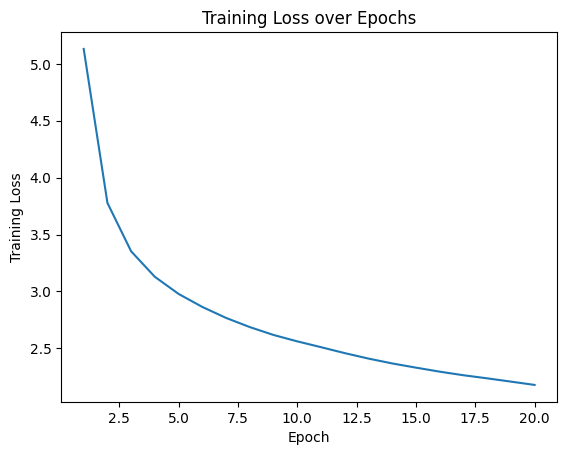

In [23]:
# Cell 10: Plot training loss over epochs
# ---------------------------------------
# Use the `history` object returned by model.fit
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs_range = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs_range, loss)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss over Epochs')
plt.show()

In [25]:
# Cell 11: Generate caption for a given image and evaluate BLEU

def generate_caption(model, tokenizer, photo_feature, max_length):
    # Start with the start token
    in_text = 'startseq'
    for i in range(max_length):
        # Convert the current caption into a sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # Ensure right-padding by specifying padding='post'
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        # Predict the next word using the model
        yhat = model.predict([photo_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)

        # Map the predicted integer back to the corresponding word
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        if word is None:
            break
        in_text += ' ' + word
        # If end token is predicted, stop further prediction
        if word == 'endseq':
            break
    return in_text

# Evaluate on a few samples (for full evaluation, compare with multiple reference captions)
actual, predicted = list(), list()
for img_name, caps in list(captions_dict.items())[:10]:
    photo_feature = features_dict[img_name]
    y_pred = generate_caption(model, tokenizer, photo_feature, max_length)
    # Remove start and end tokens for evaluation
    predicted.append(y_pred.split()[1:-1])
    # Assume the first caption as reference (or use all available)
    actual_caption = caps[0].split()[1:-1]
    actual.append([actual_caption])
    print("Actual:", ' '.join(actual_caption))
    print("Predicted:", ' '.join(y_pred.split()[1:-1]))
    print()

# Compute BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
print("BLEU-3: %f" % corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0)))
print("BLEU-4: %f" % corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))


Actual: a child in a pink dress is climbing up a set of stairs in an entry way
Predicted: a man in a blue shirt is sitting on a bench with a stuffed animal

Actual: a black dog and a spotted dog are fighting
Predicted: a black dog and a black dog are playing with each other on the grass

Actual: a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl
Predicted: a girl in a pink shirt is jubilant while a man in a red shirt is jubilant

Actual: a man lays on a bench while his dog sits by him
Predicted: a man and a woman are sitting on a bench

Actual: a man in an orange hat starring at something
Predicted: a man in a blue shirt and sunglasses is wearing a blitz hat

Actual: a child playing on a rope net
Predicted: a little girl in a red shirt is climbing a swing

Actual: a black and white dog is running in a grassy garden surrounded by a white fence
Predicted: a dog is biting a black and white dog

Actual: a dog shakes its head near the shore a red ball

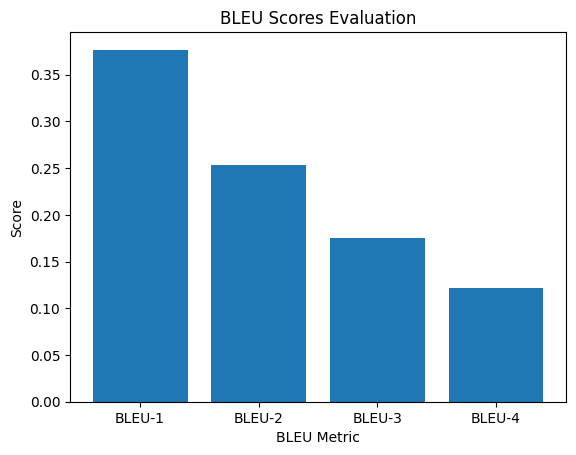

In [26]:
# Cell 12: BLEU score bar chart
# -----------------------------
#plot previously computed BLEU scores
bleu_scores = {
    'BLEU-1': corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)),
    'BLEU-2': corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)),
    'BLEU-3': corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0)),
    'BLEU-4': corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)),
}

plt.figure()
plt.bar(bleu_scores.keys(), bleu_scores.values())
plt.xlabel('BLEU Metric')
plt.ylabel('Score')
plt.title('BLEU Scores Evaluation')
plt.show()

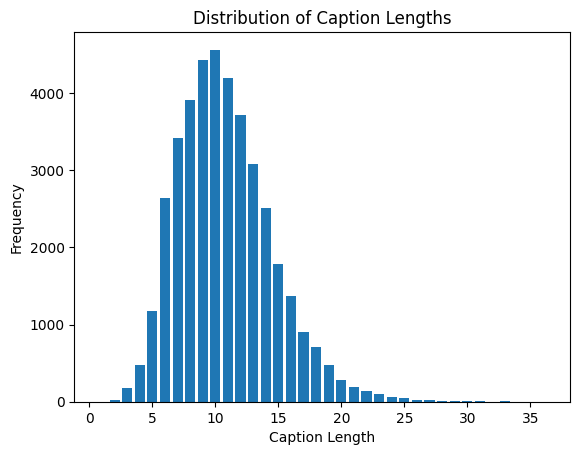

In [27]:
# Cell 13: Caption length distribution
# ------------------------------------
# Visualize how caption lengths vary
from collections import Counter

# Compute lengths (excluding start/end tokens)
lengths = [len(cap.split()) - 2 for cap in all_captions]
counter = Counter(lengths)
lengths_list, counts = zip(*sorted(counter.items()))

plt.figure()
plt.bar(lengths_list, counts)
plt.xlabel('Caption Length')
plt.ylabel('Frequency')
plt.title('Distribution of Caption Lengths')
plt.show()

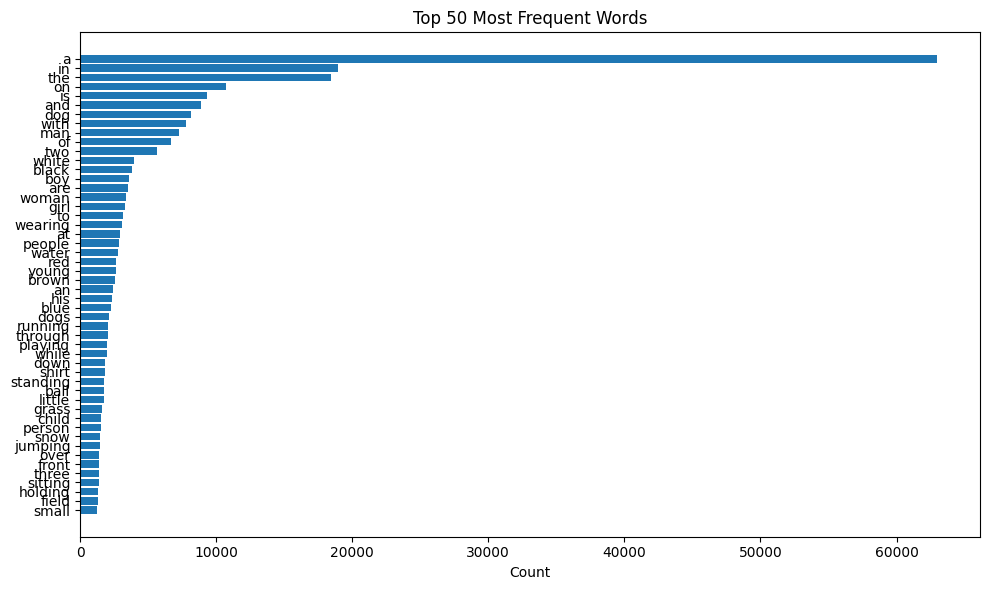

In [28]:
# Cell 14: Word frequency (top 50 words)
# ---------------------------------------
# Plot the most common words in captions (excluding tokens)
import numpy as np

# Get word index -> word and counts from tokenizer.word_counts
word_counts = tokenizer.word_counts  # OrderedDict
# Remove startseq and endseq
word_counts.pop('startseq', None)
word_counts.pop('endseq', None)

# Take top 50
common = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:50]
words, freqs = zip(*common)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], freqs[::-1])  # horizontal bar chart
plt.xlabel('Count')
plt.title('Top 50 Most Frequent Words')
plt.tight_layout()
plt.show()

Image: 1000268201_693b08cb0e.jpg


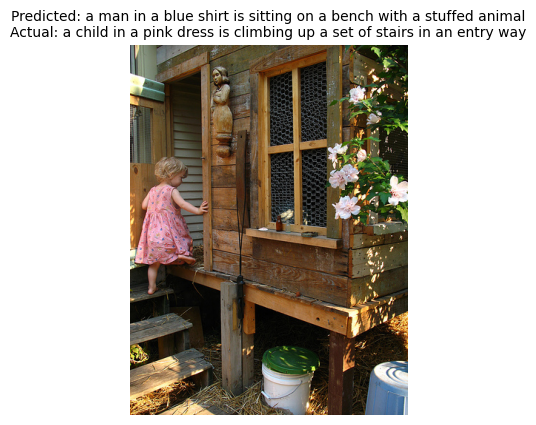

Image: 1001773457_577c3a7d70.jpg


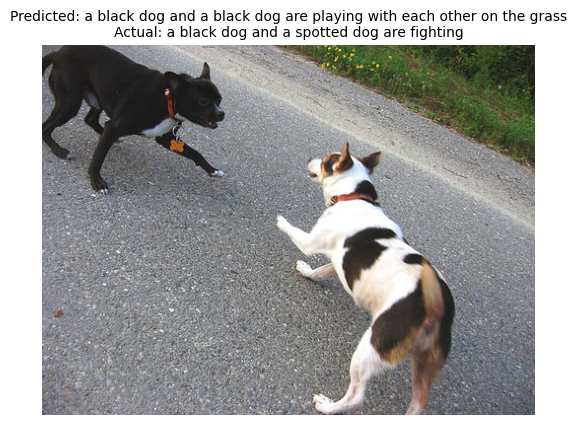

Image: 1002674143_1b742ab4b8.jpg


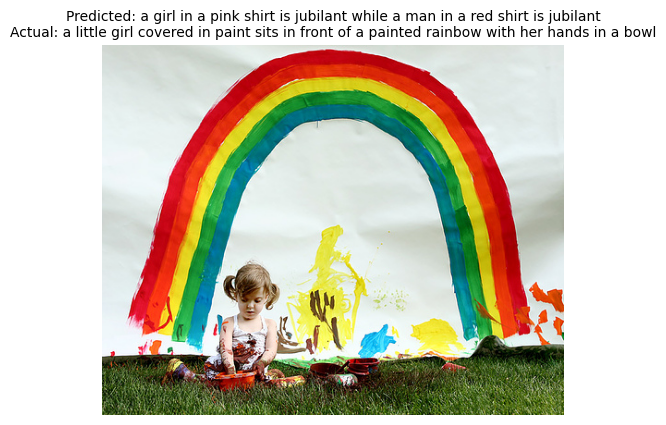

In [29]:
# Cell 15: Visualize sample predictions from the image captioning model

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_caption(image_path, predicted_caption, actual_captions):
    """Display an image with its predicted caption and actual captions."""
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.axis('off')
    # Create a title string that includes the predicted caption and a reference caption
    # (You can extend this to include multiple references if needed)
    title_str = f"Predicted: {predicted_caption}\nActual: {actual_captions}"
    plt.title(title_str, fontsize=10)
    plt.show()

# Number of samples you want to visualize; adjust as needed.
num_samples = 3
images_folder = '/content/Images'

for i, (img_name, captions) in enumerate(captions_dict.items()):
    if i >= num_samples:
        break
    photo_feature = features_dict[img_name]
    # Generate a caption for the current image
    generated = generate_caption(model, tokenizer, photo_feature, max_length)
    # Remove the start and end tokens for a cleaner display
    generated_clean = ' '.join(generated.split()[1:-1])

    # For reference, we pick the first caption (or you could combine multiple references)
    actual_caption_clean = ' '.join(captions[0].split()[1:-1])

    image_path = os.path.join(images_folder, img_name)
    print(f"Image: {img_name}")
    display_caption(image_path, generated_clean, actual_caption_clean)


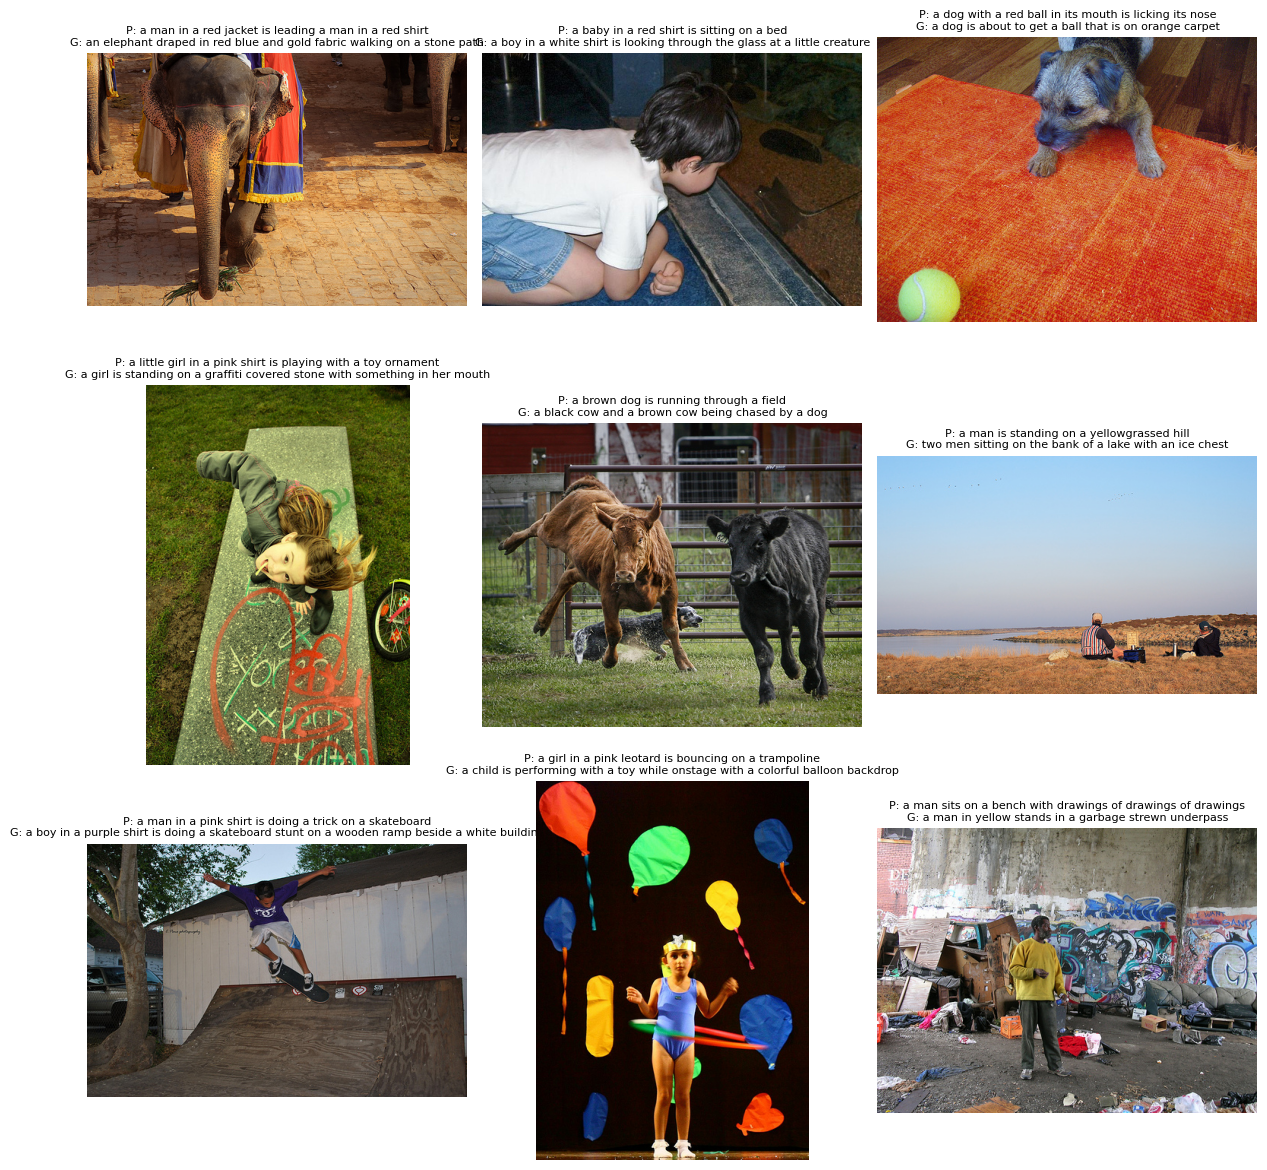

In [30]:
# Cell 16: Grid of sample predictions
# -----------------------------------
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from random import sample

# Draw 9 random images
random_imgs = sample(list(captions_dict.keys()), 9)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, img_name in zip(axes, random_imgs):
    feature = features_dict[img_name]
    pred = generate_caption(model, tokenizer, feature, max_length).split()[1:-1]
    gt = captions_dict[img_name][0].split()[1:-1]
    img = mpimg.imread(os.path.join(images_folder, img_name))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"P: {' '.join(pred)}\nG: {' '.join(gt)}", fontsize=8)

plt.tight_layout()
plt.show()